#  Prédiction de la Pluie en Australie

**Problématique :** Diviser les données en training et test pour prédire la pluie en Australie (`RainTomorrow`)

**Groupe :** Marina Moumou, Melike Demiray, Cloé Hanauer


---
###  Plan 
1. Import des librairies
2. Chargement exploration des données
3. Analyse exploratoire (EDA)
4. Prétraitement des données
5. Séparation Train / Test
6. Prédiction (Régression logistique, algorithmes de boosting)
7. Évaluation et comparaison des modèles
8. Conclusion

---
## 1.  Import des librairies

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

---
## 2.  Chargement BDD et visualisation de la base

In [2]:
df = pd.read_csv('weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

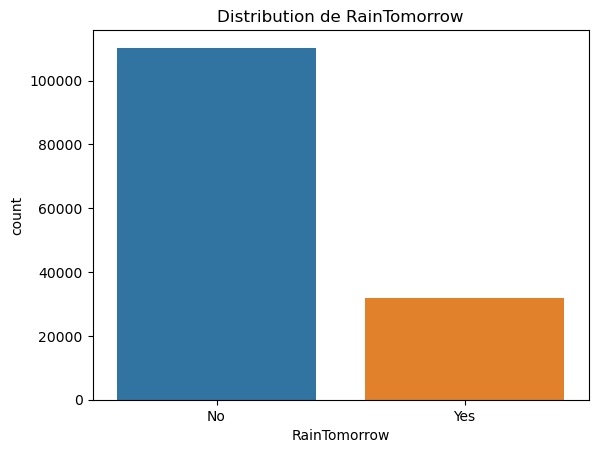

In [4]:
sns.countplot(x='RainTomorrow', data=df)
plt.title('Distribution de RainTomorrow')
plt.show()

In [5]:
# Statistiques descriptives
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [6]:
# ── Valeurs manquantes ────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).query('`Valeurs manquantes` > 0').sort_values('Pourcentage (%)', ascending=False)

print(" Colonnes avec valeurs manquantes :")
display(missing_df)



 Colonnes avec valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


**Analyse :**

Le bdd contient 145 460 observations et 23 variables. Il s’agit donc d’une base relativement volumineuse, ce qui est favorable pour entraîner des modèles de machine learning.
On observe que les variables sont de deux types principaux :
- 16 variables numériques de type `float64`, comme les températures, l’humidité, la pression ou la vitesse du vent 
- 7 variables catégorielles de type `str`, comme la localisation, la direction du vent, `RainToday` et la variable cible `RainTomorrow`.

La variable cible du projet est `RainTomorrow`, qui indique s’il pleuvra ou non le lendemain. Cette variable contient cependant 3 267 valeurs manquantes. Comme il s’agit de la variable à prédire, les lignes concernées devront être supprimées avant la modélisation

L’analyse des valeurs manquantes montre également que certaines variables présentent un taux de données manquantes très élevé, notamment :
- `Sunshine` avec 69 835 valeurs manquantes 
- `Evaporation` avec 62 790 valeurs manquantes 
- `Cloud9am` avec 55 888 valeurs manquantes 
- `Cloud3pm` avec 59 358 valeurs manquantes

Ces variables devront faire l’objet d’un traitement particulier : soit être supprimées, soit être imputées si l’on considère qu’elles apportent une information utile au modèle

À l’inverse, certaines variables comme `Date` et `Location` ne contiennent aucune valeur manquante, ce qui est intéressant pour l’analyse temporelle et géographique

---
## 3.  Analyse en profondeur des variables

Text(0.5, 1.0, 'MeanDayTemp')

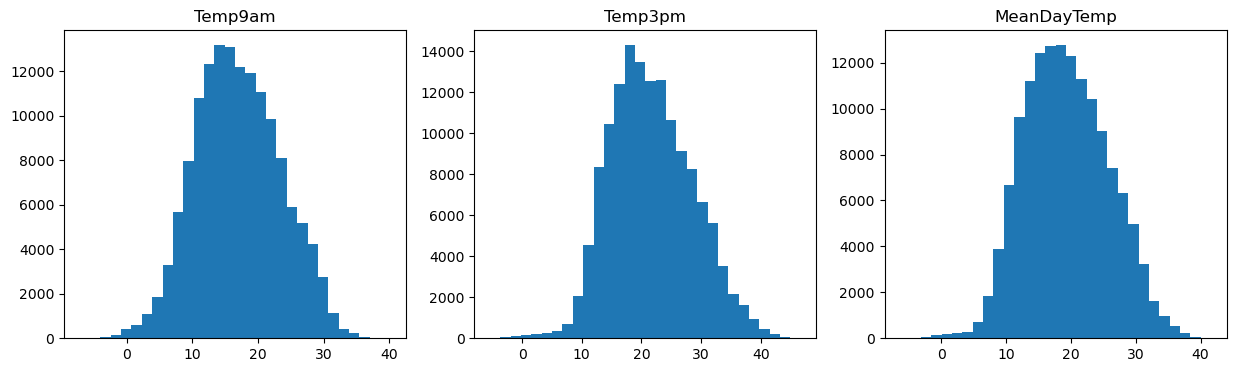

In [7]:
# Distribution de la tempréature selon l'heure de la journée et température moyenne avec plotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['MeanDayTemp'] = (df['Temp9am'] + df['Temp3pm'])/2
axes[0].hist(df['Temp9am'], bins=30)
axes[0].set_title('Temp9am')
axes[1].hist(df['Temp3pm'], bins=30)
axes[1].set_title('Temp3pm')
axes[2].hist(df['MeanDayTemp'], bins=30)
axes[2].set_title('MeanDayTemp')

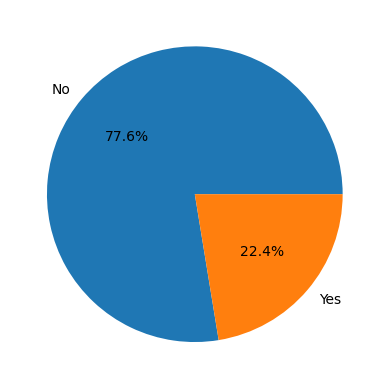

In [8]:
# Distribution des prédictions des jours de pluie du lendemain (RainTomorrow) avec plotlib
counts = df['RainTomorrow'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.show()

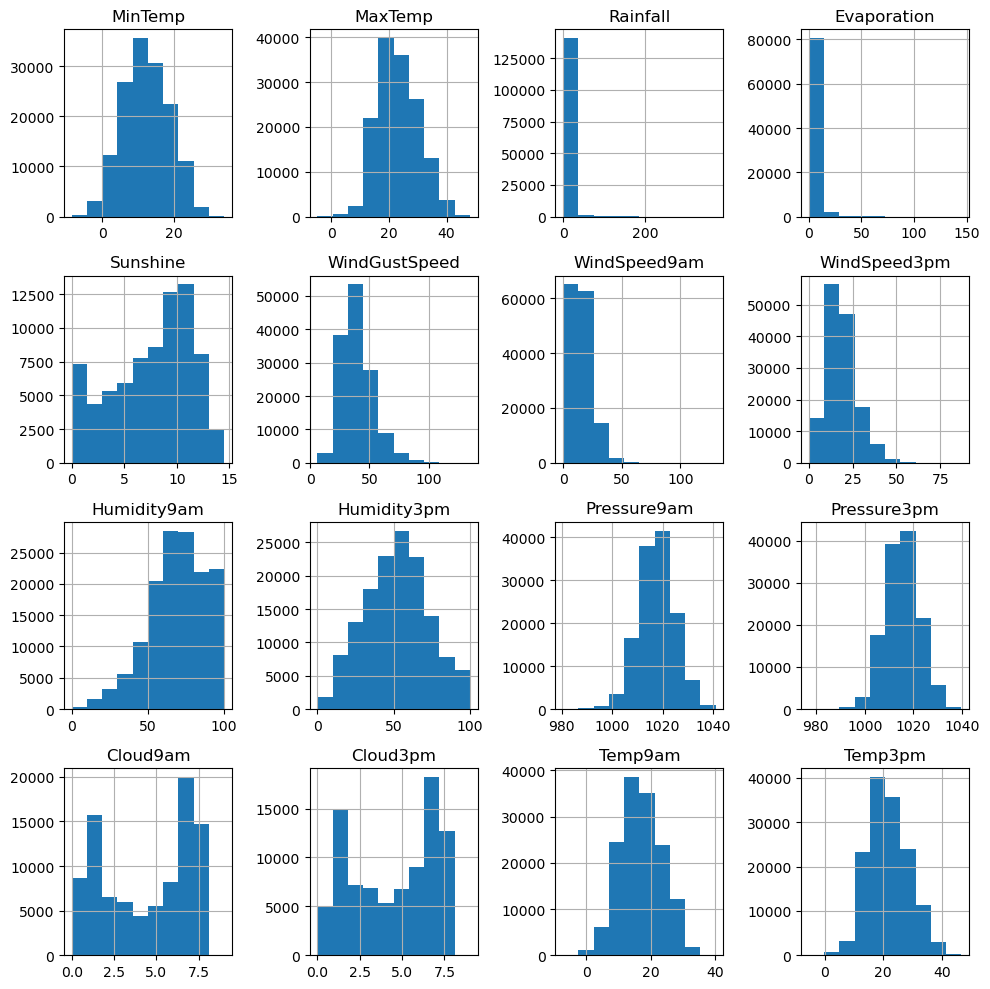

In [9]:
# Distribution des autres variables numériques 
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 10))
for i, col in enumerate(num_cols[:16]):  # on limite ici
    plt.subplot(4, 4, i + 1)
    df[col].hist()
    plt.title(col)
#on ajuste l'espacement entre les graphiques avec tight_layout pour plus de visibilité
plt.tight_layout()
plt.show()

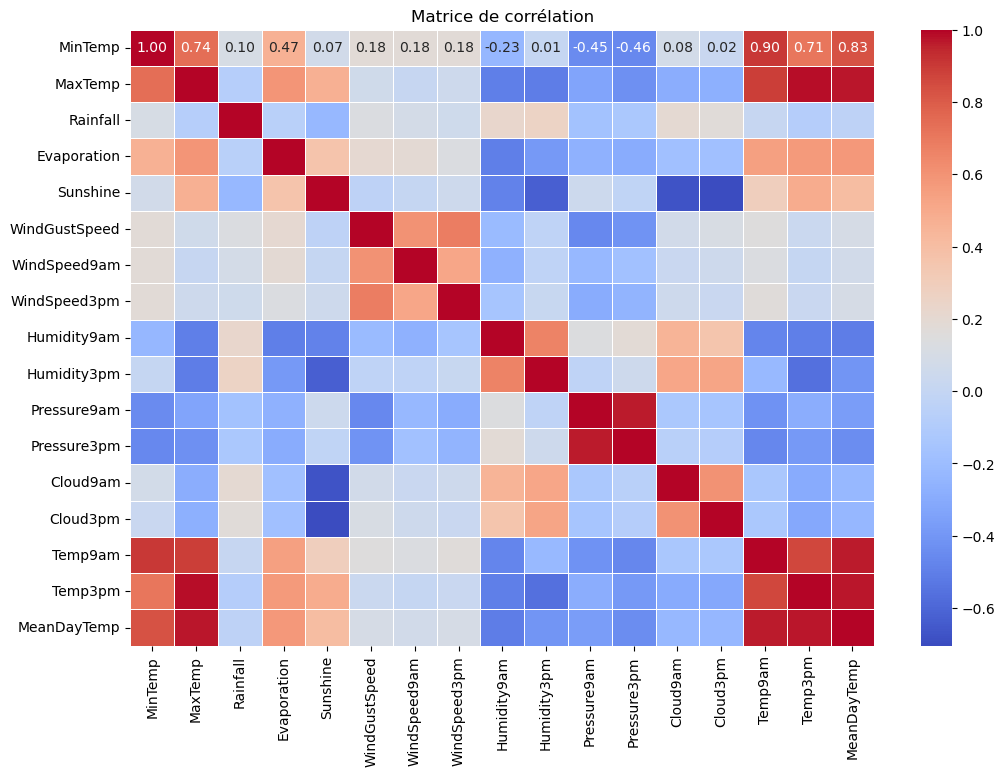

In [10]:
# Matrice de corrélation 
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm',  annot=True, fmt=".2f",linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

L’analyse met en évidence plusieurs éléments importants :

Certaines variables présentent des distributions asymétriques, notamment Rainfall, avec une majorité de valeurs faibles et quelques valeurs extrêmes

La matrice de corrélation révèle des relations fortes entre certaines variables, notamment entre les températures, les pressions et les vitesses du vent, indiquant une possible redondance de l’information.

Nous remarquons également des corrélations évidentes, comme la corrélation négative entre les nuages et le soleil, ou encore comme la température minimum et maximum.

Ces résultats permettent d’orienter le nettoyage des données, en identifiant les variables à transformer, à conserver ou éventuellement à supprimer

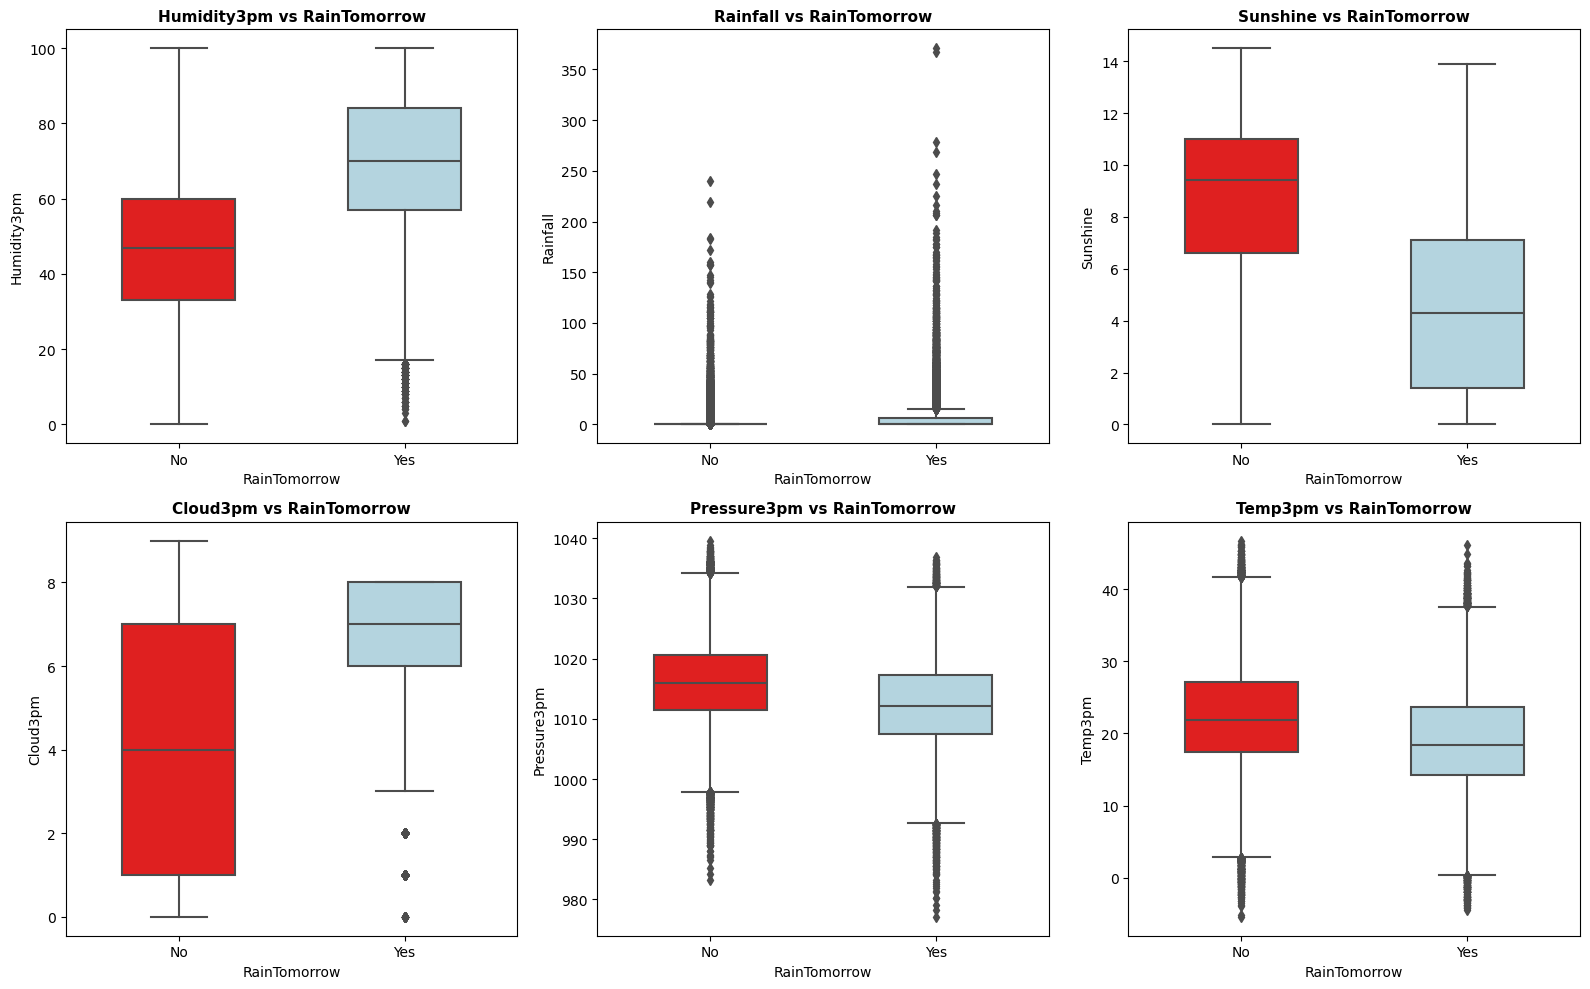

In [11]:
# Analyse en boite à moustaches : Boxplots — variables possiblement prédictives vs RainTomorrow
key_vars = ['Humidity3pm', 'Rainfall', 'Sunshine', 'Cloud3pm','Pressure3pm', 'Temp3pm']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
palette = {'No': 'red', 'Yes': 'lightblue'}
# pour chaque variable possiblement prédictive :
for i, col in enumerate(key_vars):
    sns.boxplot(data=df, x='RainTomorrow', y=col,
                palette=palette, ax=axes[i], width=0.5)
    axes[i].set_title(f'{col} vs RainTomorrow',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('RainTomorrow')
plt.tight_layout()
plt.show()

**Humidité à 15h** : Généralement, plus il fait humide à 15h au jour J, plus il est probable qu'il pleuve le lendemain.

**Nuages à 15h** : On remarque que quand il est prédit de la pluie pour le lendemain, généralement, le jour J, le ciel est pratiquement toujours extrêment couvert (sauf valeurs aberrantes) 

**Soleil** : A l'inverse et de façon logique, la présence de soleil tend à diminuer la probabilité de pluie le lendemain.

**Pression à 15h** : Les boites à moustache sont assez similaire, ce qui veux peut être dire que la pression n'influe pas ou que la pression est souvent identique aux mêmes endroits.

**Température à 15h** : La température n'a pas l'air de grandement influer sur la probabilité de pluie à J+1, même si on remaruqe une légère tendance à ce qu'il pleuve quand il fait un peu plus froid, mais rien de concluant



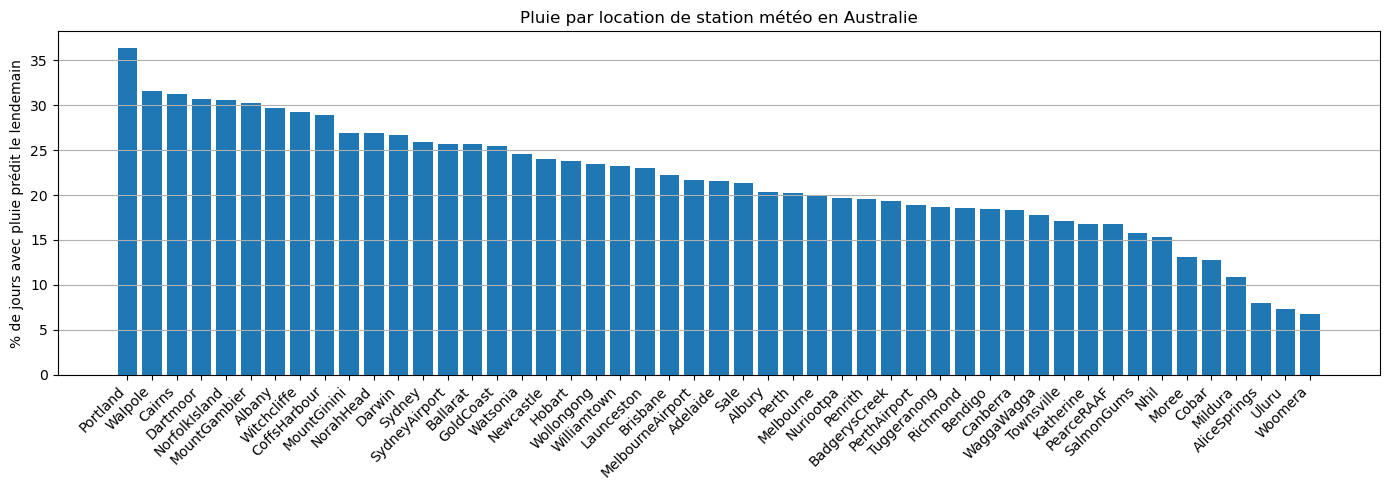

In [12]:
# Pluviométrie par localisation 
rain_by_loc = df.groupby('Location')['RainTomorrow'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(14,5))
plt.bar(rain_by_loc.index, rain_by_loc.values)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.ylabel('% de jours avec pluie prédit le lendemain')
plt.title('Pluie par location de station météo en Australie')

plt.tight_layout()
plt.show()

---
## 4.  Prétraitement des données

**Étapes :**
1. Suppression de la colonne `Date` (ou extraction de features temporelles)
2. Encodage des variables catégorielles
3. Traitement des valeurs manquantes
4. Normalisation / Standardisation

### ATTENTION, ON NE PEUT PAS GARDER LES LIGNES OU RAINTOMORROW EST INCONNUE DONC ON LES SUPPRIME CAR ON NE PEUT PAS LES REMPLACER PAR LA MEDIANE

In [13]:
TARGET = "RainTomorrow"

df[TARGET] = df[TARGET].map({'No': 0, 'Yes': 1})
df_new = df.dropna(subset=[TARGET]).copy()
print("df_new :", df_new.shape)

df_new : (142193, 24)


In [14]:
# Encodage date
df_new['Date'] = pd.to_datetime(df_new['Date'])
df_new['Year'] = df_new['Date'].dt.year
df_new['Month'] = df_new['Date'].dt.month
df_new = df_new.drop('Date', axis=1)

In [15]:
# Encodage des variables catégorielles
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    df_new[col] = df_new[col].fillna('Unknown')
    le = LabelEncoder()
    df_new[col] = le.fit_transform(df_new[col])  # ← INDENTATION CRITIQUE !

In [16]:
# Imputation des valeurs manquantes 
print(f"Valeurs manquantes avant imputation : {df_new.isnull().sum().sum():,}")

# Imputation par la médiane (robuste aux outliers)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df_new_imputed = pd.DataFrame(imputer.fit_transform(df_new),
                             columns=df_new.columns)

print(f"Valeurs manquantes après imputation : {df_new_imputed.isnull().sum().sum()}")

Valeurs manquantes avant imputation : 295,309
Valeurs manquantes après imputation : 0


In [17]:
#  Identification colonnes features / cible 
#TARGET = "RainTomorrow"
FEATURES = [col for col in df_new_imputed.columns if col != TARGET]
X = df_new_imputed[FEATURES]
y = df_new_imputed[TARGET].astype(int)

print(f" Dimensions X : {X.shape}")
print(f" Dimensions y : {y.shape}")

print(f" Dimensions X : {X.shape}")
print(f" Dimensions y : {y.shape}")
print(f"\nFeatures (variables) utilisées ({len(FEATURES)}) :")
print(FEATURES)

 Dimensions X : (142193, 24)
 Dimensions y : (142193,)
 Dimensions X : (142193, 24)
 Dimensions y : (142193,)

Features (variables) utilisées (24) :
['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'MeanDayTemp', 'Year', 'Month']


---
## 5.  Séparation Train / Test

On utilise `train_test_split` de scikit-learn pour créer aléatoirement deux sous-ensembles avec :
- **80 % de l'ensemble → Training** (apprentissage)
- **20 % de l'ensemble → Test** (évaluation)
- `stratify=y` pour conserver le ratio de classes dans chaque split
- `random_state=42` pour la reproductibilité

In [18]:
# SÉPARATION TRAIN / TEST 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rain_train = (y_train == 1).mean() * 100
rain_test = (y_test == 1).mean() * 100

print(f"Train : {len(X_train):,} obs                         | Test : {len(X_test):,} obs")
print(f"Proportion de pluie (Yes=1) → Train : {rain_train:.1f}% | Test : {rain_test:.1f}%")

Train : 113,754 obs                         | Test : 28,439 obs
Proportion de pluie (Yes=1) → Train : 22.4% | Test : 22.4%


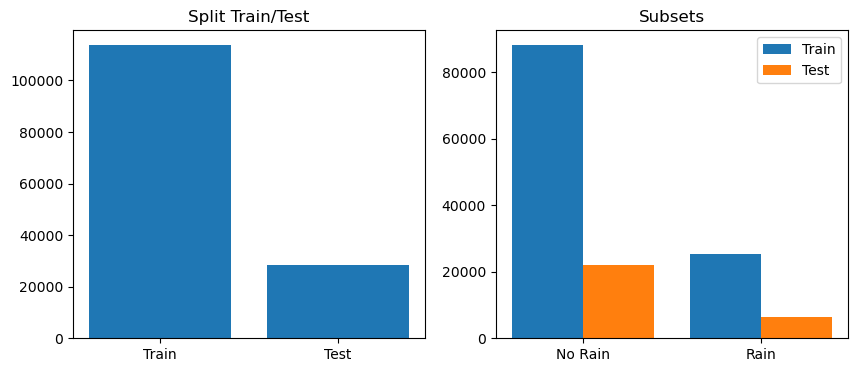

In [19]:
# Visualisation des sous ensembles 
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(['Train','Test'], [len(X_train), len(X_test)])
plt.title('Split Train/Test')

plt.subplot(1,2,2)

x = np.arange(2)
plt.bar(x - 0.2, [(y_train==0).sum(), (y_train==1).sum()], width=0.4, label='Train')
plt.bar(x + 0.2, [(y_test==0).sum(), (y_test==1).sum()], width=0.4, label='Test')

plt.xticks(x, ['No Rain', 'Rain'])
plt.title('Subsets')
plt.legend()
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Mean : {X_train_scaled.mean():.2f} | Std : {X_train_scaled.std():.2f}")

Mean : 0.00 | Std : 1.00


---
## 6.  Prédictions

On teste 2 modèles de prédiction :

| Modèle |
|---|
| Régression logistique (logit) |
| Algorithmes de boosting |

Le modèle logit (régression logistique) permet d’estimer la probabilité qu’un événement se produise, ici la pluie le lendemain, en fonction de variables météorologiques telles que la température, l’humidité ou la pression. Contrairement à la régression linéaire, il est adapté à une variable binaire, car ses prédictions sont born entre 0 et 1 et peuvent être interprétées comme des probabilités.

Le boosting est une méthode d’apprentissage automatique qui combine plusieurs modèles simples pour améliorer progressivement la qualité des prédictions chaque modèle corrige les erreurs du précédent (d'où la séparation des données avant cette étape). Cette méthode est particulièrement adaptée à la prédiction de la pluie car elle offre généralement de meilleures performances que les modèles plus simples comme la régression logistique.

### Régression logistique avec modèle logit

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Modèle de régression logistique
lr = LogisticRegression(penalty='l2',C=1.0,solver='liblinear',max_iter=100)

# Entraînement du modèle
lr.fit(X_train, y_train)

# Prédictions
y_pred = lr.predict(X_test)

# Probabilités (classe "RainTomorrow" = 1)
y_proba = lr.predict_proba(X_test)[:, 1]

# Évaluation
score = accuracy_score(y_test, y_pred)

print("Score de la régression logistique =", score)

Score de la régression logistique = 0.8452828861774324


In [23]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred, target_names=['Pas de pluie', 'Pluie']))

# Courbe ROC
y_proba = lr.predict_proba(X_test)[:, 1]
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

Pas de pluie       0.87      0.95      0.90     22064
       Pluie       0.73      0.49      0.59      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.72      0.75     28439
weighted avg       0.84      0.85      0.83     28439

ROC-AUC : 0.867
[[20896  1168]
 [ 3232  3143]]


Sur 28439 test, le modèle prédit correctement 85% des cas.

**Pas de pluie :**

Precision : 87% --> Parmi "pas de pluie" prédits, 87% sont vrais

Recall    : 95% --> Parmi vrais "pas de pluie", 95% détectés



**Pluie :**

Precision : 73% → Parmi "pluie" prédits, 73% sont vrais

Recall    : 49% → Parmi vrais "pluie", 49% détectés  

Le coefficient de la courbe ROC est très proche de 1, le modèle est excellent

**Finalement, quelles sont les variables qui prédisent le mieux la probabilité de pleuvoir le lendemain du Jour-J ?**

In [35]:
coef_df = pd.DataFrame({
    'variable': X_train.columns,
    'coefficient': lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0]),  # exp(coef) = multiplication du risque
    'importance': np.abs(lr.coef_[0])
}).sort_values('importance', ascending=False)

# Top 5
print(coef_df[['variable', 'coefficient', 'odds_ratio']].round(3).head(7).to_string(index=False))

     variable  coefficient  odds_ratio
    RainToday        0.298       1.347
  Pressure3pm       -0.186       0.831
     Cloud3pm        0.127       1.136
  Pressure9am        0.126       1.135
     Sunshine       -0.109       0.897
  Humidity3pm        0.054       1.056
WindGustSpeed        0.051       1.052


## Intéprétation des coefficients

RainToday : coef = +0.298 (odds = 1.35)
S'il pleut aujourd'hui → 1.35x PLUS de risque de pluie le lendemain

Pressure3pm : coef = -0.186 (odds = 0.83)
+1 hPa de pression à 15h → 17% MOINS de risque de pluie le lendemain

Cloud3pm : coef = +0.127 (odds = 1.14)
+1 okta de nuages à 15h → 14% PLUS de risque de pluie le lendemain

Pressure9am : coef = +0.126 (odds = 1.14)
-1 hPa de pression le matin → 14% PLUS de risque de pluie le lendemain

Sunshine : coef = -0.109 (odds = 0.90)
+1h soleil à 15h → 10% MOINS de risque de pluie le lendemain

#  BOOSTING 

Après avoir testé une régression logistique, nous testons un modèle de Gradient Boosting, ce modèle appartient à la famille des méthodes d’ensemble : il combine plusieurs arbres de décision afin d’améliorer la qualité des prédictions

---
## 1.  Import et entraînement du modèle


In [25]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

# On instancie le modèle de Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)

# On entraîne le modèle sur les données d'apprentissage
gb.fit(X_train, y_train)

# On prédit sur les données de test
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

## 2. Evaluation du modèle

In [27]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Score global
score_gb = accuracy_score(y_test, y_pred_gb)
print("Accuracy :", round(score_gb, 3))

# Rapport détaillé
print(classification_report(y_test, y_pred_gb, target_names=['Pas de pluie', 'Pluie']))

# Courbe ROC
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_gb), 3))

Accuracy : 0.851
              precision    recall  f1-score   support

Pas de pluie       0.87      0.95      0.91     22064
       Pluie       0.75      0.50      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.81      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439

ROC-AUC : 0.877


## Intéprétation 

le modèle atteint une accuracy de 85.1% légèrement supérieure à la régression logistique 

PAS DE PLUIE : bien détecté avec un recall de 95%
PLUIE : plus difficile à prédire, avec un recall de seulement 50% le modèle rate encore un jour de pluie sur deux , ce qui s'explique par le déséquilbre des classes

La courbe ROC-AUC de 0.877 confirme que le modèle est globalement performant

## 3. Matrice de confusion


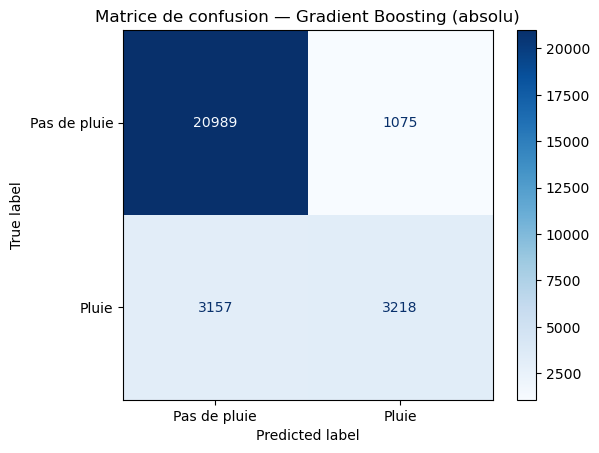

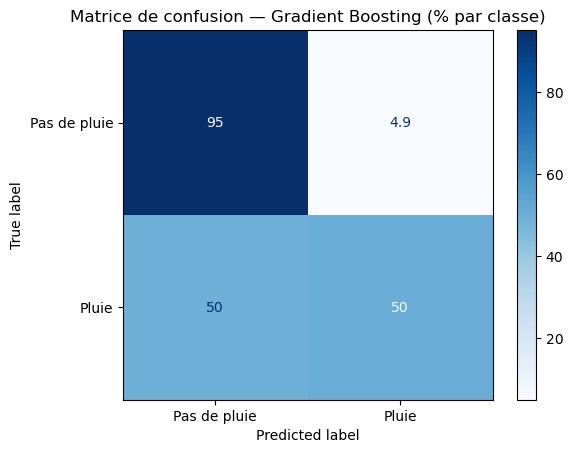

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrice d'observations
cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pas de pluie', 'Pluie'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion — Gradient Boosting (absolu)')
plt.show()

# Matrice en % 
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
disp_pct = ConfusionMatrixDisplay(confusion_matrix=cm_pct.round(1), display_labels=['Pas de pluie', 'Pluie'])
disp_pct.plot(cmap='Blues')
plt.title('Matrice de confusion — Gradient Boosting (% par classe)')
plt.show()

## interpretation 

La matrice confirme les résultats précdents :
- 20989 jours sans pluie correctement prédits 
- 3218 jours de pluie correctement prédits 
- 1075 faux positifs : le modèle prédit de la pluie alors qu'il n'y en a pas 
- 3157 faux négatifs : le modèle prédit " pas de pluie" alors qu'il pleut

95% des jours non pluvieux sont bien prédit par le modèle. Concernant les jours de plus, c'est seulement 50%.

## 4.Importance des variables 

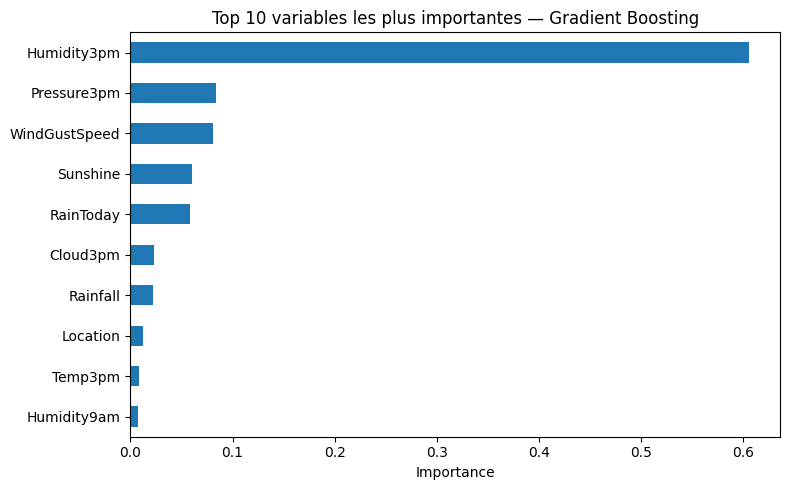

In [33]:
importances = pd.Series(gb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True).tail(10)

importances.plot(kind='barh', figsize=(8, 5))
plt.title('Top 10 variables les plus importantes — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

HUMIDITY3PM : domine largement avec un score de 0.60, l'humidité à 15h est de loin la variable la plus prédictive, c'est cohérant avec ce qu'on observait deja avec les boxplots

Ensuite viennent PRESSURE3PM et WINDGUSTSPEED (environ 0.08 chacune), puis SUNSHINE et RAINTODAY (environ 0.05)

Les autres variables comme TEMP3PM , LOCATION ou HUMIDITY9AM ont une importance quasi nulle, elles n'apportent presque rein au modèle

EN RESUME : le modèle repose essentiellement sur l'humidité de fin de journée pour prédire la pluie du lendemain, ce qui est météorologiquement logique 

Les prédicteurs ne sont pas les mêmes que ceux trouvé avec la régréssion logistique


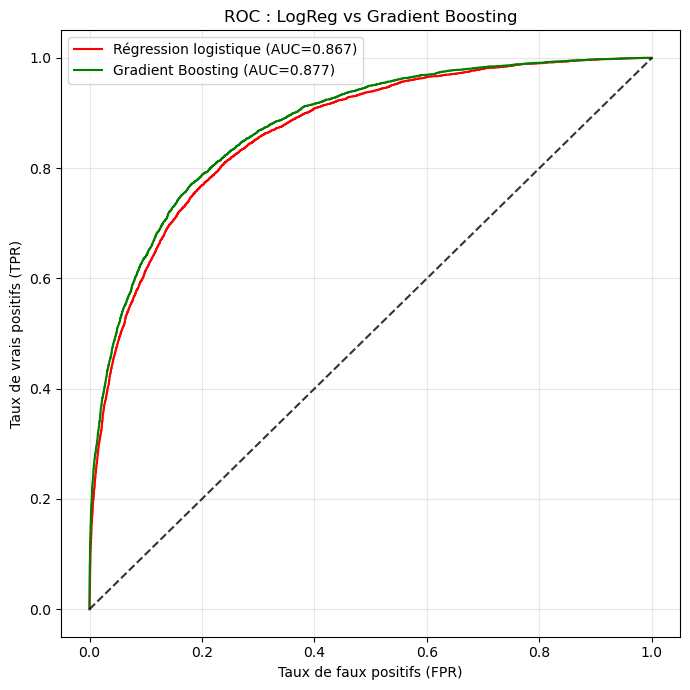

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# taille graphique
fig, ax = plt.subplots(figsize=(7,7))

# LogisticRegression
rocfp_lr, rocvp_lr, _ = roc_curve(y_test, y_proba) 
ax.plot(rocfp_lr, rocvp_lr, color='red', label=f'Régression logistique (AUC={roc_auc_score(y_test, y_proba):.3f})')

# Gradient Boosting
rocfp_gb, rocvp_gb, _ = roc_curve(y_test, y_proba_gb)
ax.plot(rocfp_gb, rocvp_gb, color='green', label=f'Gradient Boosting (AUC={roc_auc_score(y_test, y_proba_gb):.3f})')

# Diagonale
ax.plot([0, 1], [0, 1], 'k--', alpha=0.8)

ax.set(title='ROC : LogReg vs Gradient Boosting', xlabel='Taux de faux positifs (FPR)', ylabel='Taux de vrais positifs (TPR)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Comparaison avec la regression logistique 

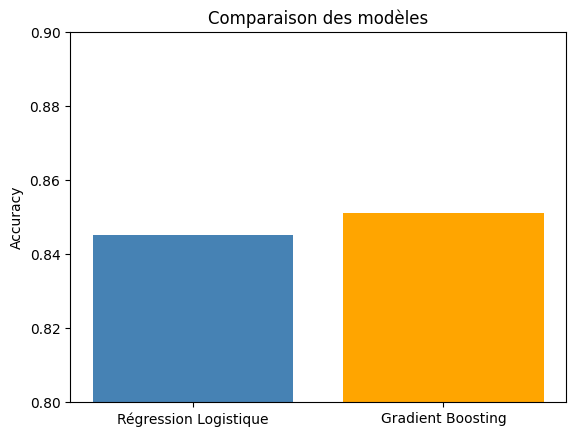

In [34]:
resultats = {
    'Régression Logistique': accuracy_score(y_test, y_pred),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb)
}

plt.bar(resultats.keys(), resultats.values(), color=['steelblue', 'orange'])
plt.ylim(0.8, 0.9)
plt.ylabel('Accuracy')
plt.title('Comparaison des modèles')
plt.show()

Le Gradient Boosting (85.1%) fait légèrement mieux que la régression logistique (84.5%), mais l'écart reste faible

La régression logistique est donc déjà un bon modèle sur ces données. Le Gradient Boosting apporte une amélioration marginale, au prix d'un temps d'entraînement plus élevé. Pour un problème de prédiction de pluie avec des variables météo relativement bien structurées, les deux modèles se comportent de manière similaire